**Insight 3: Younger Employees Are More Likely to Change Jobs Frequently**<br>
Target variable: JobHopper<br>
Model: Logistic Regression<br>
<br>
already created this in Step 2:<br>
df['JobHopper'] = np.where(df['NumCompaniesWorked'] >= 3, 1, 0)<br>
<br>
Binary classification:<br>
1 = Job hopper (worked for 3 or more companies)<br>
0 = Stable employee (worked for fewer than 3)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("cleaned_employee_data.csv")

In [5]:
X = df.drop(columns=['JobHopper'])  # Use full feature set
y = df['JobHopper']  # Binary target: 1 = Job hopper, 0 = Stable

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [15]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

Accuracy: 99.55%
Precision: 99.45%
Recall: 99.45%
F1 Score: 99.45%



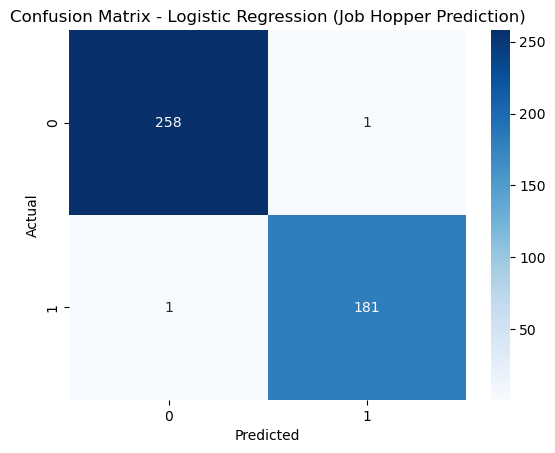

True Positives: 181
True Negatives: 258
False Positives: 1
False Negatives: 1


In [17]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred)*100:.2f}%")
print()

# Confusion Matrix - Logistic Regression
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Job Hopper Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

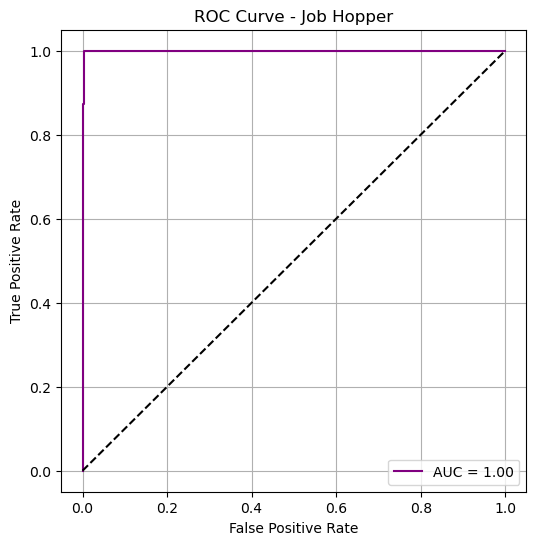

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Job Hopper")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()